In [ ]:
import os
import re
import gc
import numpy as np
import pandas as pd
import xarray as xr
import rasterio as rio
import rasterio.mask
import geopandas as gpd
import regionmask
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
import warnings
from concurrent.futures import ProcessPoolExecutor, as_completed
from shapely.geometry import box

warnings.filterwarnings("ignore")

# =====================================================================
# 1. CONFIGURATION
# =====================================================================
CEMS_DIR = Path("/gws/ssde/j25b/bas_climate/users/clelland/model/training_e5l_cems_firecci_new_fwi_with_fraction")
WIEMIP_BASE_DIR = Path("/gws/ssde/j25b/bas_climate/users/clelland/model/testing_inputs_final")
ROI_SHP_PATH = Path("/home/users/clelland/Model/rerun/problem_diagnosis/shapefile/Ecoregions2017.shp")

OUT_PLOT = Path("/home/users/clelland/Model/rerun/problem_diagnosis/covariate_time_series_clipped_comparison.png")
BEST_CELL_OUT = Path("/home/users/clelland/Model/rerun/problem_diagnosis/best_match_5deg_cell.geojson")

MODELS = ['ACCESS-CM2', 'MRI-ESM2-0']
SCENARIOS = ['ssp126', 'ssp245', 'ssp370']

FEATURES = [
    "relative_humidity", "total_precipitation_sum", 
    "temperature_2m", "temperature_2m_min", "temperature_2m_max", 
    "build_up_index", "drought_code", "duff_moisture_code", 
    "fine_fuel_moisture_code", "fire_weather_index", "initial_fire_spread_index"
]

FWI_COLS = [
    "build_up_index", "drought_code", "duff_moisture_code", 
    "fine_fuel_moisture_code", "fire_weather_index", "initial_fire_spread_index"
]

def norm_str(s): return re.sub(r"[^a-z0-9]", "", str(s).lower())

# =====================================================================
# 2. HELPER: DATA CLEANING & AGGREGATION
# =====================================================================
def clean_and_mean_pixels(df, is_wiemip=False):
    """Applies physical bounds and outlier removal to a dataframe of spatial pixels, returning the mean."""
    df = df.copy()
            
    # --- 2. PHYSICAL BOUNDS FILTER (Remove Fill Values / Artifacts) ---
    # Filtering in Kelvin
    for c in ["temperature_2m", "temperature_2m_min", "temperature_2m_max"]:
        if c in df.columns: df = df[(df[c] > 150) & (df[c] < 400)]
            
    if "total_precipitation_sum" in df.columns:
        df = df[df["total_precipitation_sum"] >= 0]
        
    for c in FWI_COLS:
        if c in df.columns: df = df[df[c] >= 0]
            
    # --- 3. OUTLIER REMOVAL (Statistical tails) ---
    cols_to_clean = [c for c in FEATURES if c != "relative_humidity" and c in df.columns]
    for c in cols_to_clean:
        q_low = df[c].quantile(0.005)
        q_high = df[c].quantile(0.995)
        df = df[(df[c] >= q_low) & (df[c] <= q_high)]
        
    # Return spatial mean of the clean pixels
    return df[FEATURES].mean().to_dict() if not df.empty else None


# =====================================================================
# 3. PHASE 1: 5-DEGREE GRID SIMILARITY SEARCH (PARALLELIZED)
# =====================================================================
print("Loading ROI Shapefile and creating 5-degree grid...")
roi_gdf = gpd.read_file(ROI_SHP_PATH)
roi_wgs84 = roi_gdf.to_crs("EPSG:4326")

# Generate 5x5 degree grid
bounds = roi_wgs84.total_bounds
minx = np.floor(bounds[0] / 5) * 5
miny = np.floor(bounds[1] / 5) * 5
maxx = np.ceil(bounds[2] / 5) * 5
maxy = np.ceil(bounds[3] / 5) * 5

polys = []
for x in np.arange(minx, maxx, 5):
    for y in np.arange(miny, maxy, 5):
        polys.append(box(x, y, x + 5, y + 5))

grid_gdf = gpd.GeoDataFrame({'geometry': polys}, crs="EPSG:4326")
grid_gdf = gpd.sjoin(grid_gdf, roi_wgs84[['geometry']], how='inner').drop_duplicates(subset='geometry').reset_index(drop=True)
grid_gdf['cell_id'] = grid_gdf.index

print(f"Generated {len(grid_gdf)} intersecting 5-degree grid cells.")

# --- 3a. Evaluate FUTURE temperature_2m (GeoTIFFs) ---

def process_future_file_for_temp(tif_path, grid_df):
    cell_sums = {cid: [] for cid in grid_df['cell_id']}
    try:
        with rio.open(tif_path) as src:
            grid_proj = grid_df.to_crs(src.crs)

            b_idx = next(
                (i for i, desc in enumerate(src.descriptions)
                 if desc and norm_str(desc) == norm_str("temperature_2m")),
                None
            )
            if b_idx is None:
                return cell_sums

            for _, row in grid_proj.iterrows():
                try:
                    out_img, _ = rasterio.mask.mask(
                        src, [row.geometry], crop=True, nodata=np.nan
                    )
                    temp_data = out_img[b_idx].flatten()
                    temp_data = temp_data[(temp_data > 150) & (temp_data < 400)]

                    if len(temp_data) > 0:
                        cell_sums[row['cell_id']].append(temp_data.mean())
                except ValueError:
                    continue
    except Exception:
        pass

    return {cid: np.mean(vals) if vals else np.nan for cid, vals in cell_sums.items()}

# --- 3b. Evaluate CEMS temperature_2m (Parallel File Processing) ---
def process_cems_file_for_temp(tif_path, grid_df):
    cell_sums = {cid: [] for cid in grid_df['cell_id']}
    try:
        with rio.open(tif_path) as src:
            grid_proj = grid_df.to_crs(src.crs)
            b_idx = next((i for i, desc in enumerate(src.descriptions) if desc and norm_str(desc) == norm_str("temperature_2m")), None)
            if b_idx is None: return cell_sums
            
            for idx, row in grid_proj.iterrows():
                try:
                    out_img, _ = rasterio.mask.mask(src, [row.geometry], crop=True, nodata=np.nan)
                    temp_data = out_img[b_idx].flatten()
                    temp_data = temp_data[(temp_data > 150) & (temp_data < 400)] # bounds filter
                    if len(temp_data) > 0:
                        cell_sums[row['cell_id']].append(temp_data.mean())
                except ValueError:
                    continue
    except Exception:
        pass
    return {cid: np.mean(vals) if vals else np.nan for cid, vals in cell_sums.items()}

print("Collecting FUTURE TIFF files...")

future_tifs = []

for model in MODELS:
    for scenario in SCENARIOS:
        folder = WIEMIP_BASE_DIR / model / scenario
        if not folder.exists():
            continue

        files = [
            f for f in folder.glob("*.tif")
            if (match := re.search(r"(\d{4})_(\d{1,2})", f.name))
            and (2026 <= int(match.group(1)) <= 2100)
        ]

        future_tifs.extend([(f, model, scenario) for f in files])

print("Parallelizing FUTURE temporal mean extraction...")

future_cell_agg = {cid: [] for cid in grid_gdf['cell_id']}

with ProcessPoolExecutor() as executor:
    futures = {
        executor.submit(process_future_file_for_temp, tif, grid_gdf): (tif, model, scenario)
        for tif, model, scenario in future_tifs
    }

    for future in tqdm(as_completed(futures), total=len(futures), desc="Processing FUTURE Grids"):
        res = future.result()

        for cid, val in res.items():
            if not np.isnan(val):
                future_cell_agg[cid].append(val)

future_means = {
    cid: np.mean(vals)
    for cid, vals in future_cell_agg.items() if vals
}

tifs = [f for f in CEMS_DIR.glob("*.tif") if (match := re.search(r"cems_e5l_firecci_(\d{4})_(\d{1,2})", f.name)) and (2001 <= int(match.group(1)) <= 2022)]
cems_cell_agg = {cid: [] for cid in grid_gdf['cell_id']}
with ProcessPoolExecutor() as executor:
    futures = {executor.submit(process_cems_file_for_temp, tif, grid_gdf): tif for tif in tifs}
    for future in tqdm(as_completed(futures), total=len(futures), desc="Processing CEMS Grids"):
        res = future.result()
        for cid, val in res.items():
            if not np.isnan(val):
                cems_cell_agg[cid].append(val)
                
# --- 3c. Find Most Similar Cell ---
best_cell_id, min_diff = None, float('inf')
for cid in grid_gdf['cell_id']:
    if cid in future_means and cid in cems_means:
        diff = abs(future_means[cid] - cems_means[cid])
        if diff < min_diff:
            min_diff, best_cell_id = diff, cid

if best_cell_id is None:
    raise ValueError("No overlapping valid grid cells found between GFDL and CEMS to establish similarity.")

print(f"\n✅ Most Similar 5-Deg Cell ID: {best_cell_id} | Absolute Temp Difference: {min_diff:.2f}")

# OVERWRITE ROI with the winning grid cell for the remainder of the script
roi_wgs84 = grid_gdf[grid_gdf['cell_id'] == best_cell_id]

# Save the winning cell geometry for future use
roi_wgs84.to_file(BEST_CELL_OUT, driver="GeoJSON")
print(f"✅ Saved winning cell geometry for future use to: {BEST_CELL_OUT}")


# =====================================================================
# 4. EXTRACT CEMS / ERA5 (FROM GEOTIFFs)
# =====================================================================
print(f"\nProcessing CEMS/ERA5 GeoTIFFs (2001-2025) for Best Cell (ID: {best_cell_id})...")

target_map = {norm_str(f): f for f in FEATURES}
target_map[norm_str("initial_spread_index")] = "initial_fire_spread_index" 

cems_yearly_data = {}

for tif_path in tqdm(tifs, desc="Reading CEMS Monthly TIFs"):
    match = re.search(r"cems_e5l_firecci_(\d{4})_(\d{1,2})", tif_path.name)
    year = int(match.group(1))
    
    with rio.open(tif_path) as src:
        roi_proj = roi_wgs84.to_crs(src.crs)
        
        try:
            out_img, _ = rasterio.mask.mask(src, roi_proj.geometry, crop=True, nodata=np.nan)
        except ValueError:
            continue
            
        b_map = {}
        for i, desc in enumerate(src.descriptions):
            n_desc = norm_str(desc)
            if n_desc in target_map:
                b_map[target_map[n_desc]] = i
                
        pixels = {std_name: out_img[idx].flatten() for std_name, idx in b_map.items()}
        df_pixels = pd.DataFrame(pixels).dropna()
        
        if not df_pixels.empty:
            clean_means = clean_and_mean_pixels(df_pixels, is_wiemip=False)
            if clean_means:
                if year not in cems_yearly_data:
                    cems_yearly_data[year] = []
                cems_yearly_data[year].append(clean_means)

cems_results = []
for year, monthly_means in cems_yearly_data.items():
    df_year = pd.DataFrame(monthly_means)
    year_mean = df_year.mean().to_dict()
    year_mean['Year'] = year
    year_mean['Source'] = "Training (ERA5/CEMS)"
    cems_results.append(year_mean)


# =====================================================================
# 5. EXTRACT FUTURE DATA (GeoTIFFs)
# =====================================================================
print("\nProcessing FUTURE GeoTIFFs (2026–2100)...")

future_results = []

for model in MODELS:
    for scenario in SCENARIOS:
        print(f"\nProcessing {model} - {scenario}...")

        folder = WIEMIP_BASE_DIR / model / scenario
        if not folder.exists():
            continue

        yearly_data = {}

        tifs = [
            f for f in folder.glob("*.tif")
            if (match := re.search(r"(\d{4})_(\d{1,2})", f.name))
            and (2026 <= int(match.group(1)) <= 2100)
        ]

        for tif_path in tqdm(tifs, desc=f"{model}-{scenario}"):

            match = re.search(r"(\d{4})_(\d{1,2})", tif_path.name)
            year = int(match.group(1))

            with rio.open(tif_path) as src:
                roi_proj = roi_wgs84.to_crs(src.crs)

                try:
                    out_img, _ = rasterio.mask.mask(
                        src, roi_proj.geometry, crop=True, nodata=np.nan
                    )
                except ValueError:
                    continue

                b_map = {}
                for i, desc in enumerate(src.descriptions):
                    n_desc = norm_str(desc)
                    if n_desc in target_map:
                        b_map[target_map[n_desc]] = i

                pixels = {
                    std_name: out_img[idx].flatten()
                    for std_name, idx in b_map.items()
                }

                df_pixels = pd.DataFrame(pixels).dropna()

                if not df_pixels.empty:
                    clean_means = clean_and_mean_pixels(df_pixels)

                    if clean_means:
                        yearly_data.setdefault(year, []).append(clean_means)

        for year, vals in yearly_data.items():
            df_year = pd.DataFrame(vals)
            year_mean = df_year.mean().to_dict()
            year_mean['Year'] = year
            year_mean['Source'] = f"{model} ({scenario})"
            future_results.append(year_mean)


# =====================================================================
# 6. COMBINE, CONVERT, & PLOT
# =====================================================================
print("\nCombining datasets...")
df_combined = pd.concat(
    [pd.DataFrame(cems_results), pd.DataFrame(future_results)],
    ignore_index=True
)

# --- POST-PROCESSING UNIT CONVERSIONS (Kelvin to Fahrenheit) ---
temp_features = ["temperature_2m", "temperature_2m_min", "temperature_2m_max"]
#for temp_col in temp_features:
#    if temp_col in df_combined.columns:
#        df_combined[temp_col] = (df_combined[temp_col] - 273.15) * 1.8 + 32

print("Generating Time Series plots...")
fig, axes = plt.subplots(4, 3, figsize=(22, 20), sharex=False)
axes = axes.flatten()

palette = {
    "Training (ERA5/CEMS)": "black",
    "ACCESS-CM2 (ssp126)": "lightblue",     
    "ACCESS-CM2 (ssp245)": "blue",     
    "ACCESS-CM2 (ssp370)": "darkblue",     
    "MRI-ESM2-0 (ssp126)": "lightsalmon",  
    "MRI-ESM2-0 (ssp245)": "red",  
    "MRI-ESM2-0 (ssp370)": "brown"
}

for i, feature in enumerate(FEATURES):
    ax = axes[i]
    for source, color in palette.items():
        df_sub = df_combined[df_combined['Source'] == source].sort_values('Year')
        
        if not df_sub.empty:
            linestyle = '-' if source == "Training (ERA5/CEMS)" else '--'
            marker = 'o' if source == "Training (ERA5/CEMS)" else ''
            
            ax.plot(
                df_sub['Year'], df_sub[feature], 
                color=color, 
                linewidth=2.5 if source == "Training (ERA5/CEMS)" else 2,
                linestyle=linestyle, marker=marker, markersize=4, label=source
            )
            
    # Add units to the specific plot titles
    plot_title = feature
    if feature in temp_features:
        plot_title = f"{feature} (K)"
    elif feature == "total_precipitation_sum":
        plot_title = f"{feature}"
        
    ax.set_title(plot_title, fontsize=14, fontweight='bold')
    ax.set_ylabel("Annual Spatial Mean")
    ax.grid(True, linestyle=':', alpha=0.7)
    if i == 0:
        ax.legend(loc='best', fontsize=10)

# Clean up empty subplots
for j in range(len(FEATURES), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(f"Annual Mean Covariates (Best 5° Cell Match: {best_cell_id}): ERA5/CEMS vs FUTURE", fontsize=24, fontweight='bold', y=1.02)
plt.tight_layout()

plt.savefig(OUT_PLOT, dpi=300, bbox_inches='tight')
print(f"\n✅ Plot saved to: {OUT_PLOT}")

plt.show()
plt.close()

Loading ROI Shapefile and creating 5-degree grid...
Generated 1437 intersecting 5-degree grid cells.
Parallelizing FUTURE temporal mean extraction...


Processing FUTURE Grids:  56%|█████▌    | 2998/5400 [09:46<09:53,  4.05it/s]

Loading XGBoost Model...
Loading saved 5-degree winning cell...

Processing Model: ACCESS-CM2 (ssp126) | Year: 2026 | Month: 7 | Source: PARQUET
  Filtering pixels geographically...
  Aggregating 845 pixels...
  Generating SHAP values...
✅ Plot saved to: /home/users/clelland/Model/rerun/problem_diagnosis/shapley_waterfalls/SHAP_5deg_AOI_ACCESS-CM2 (ssp126)_2026_07.png


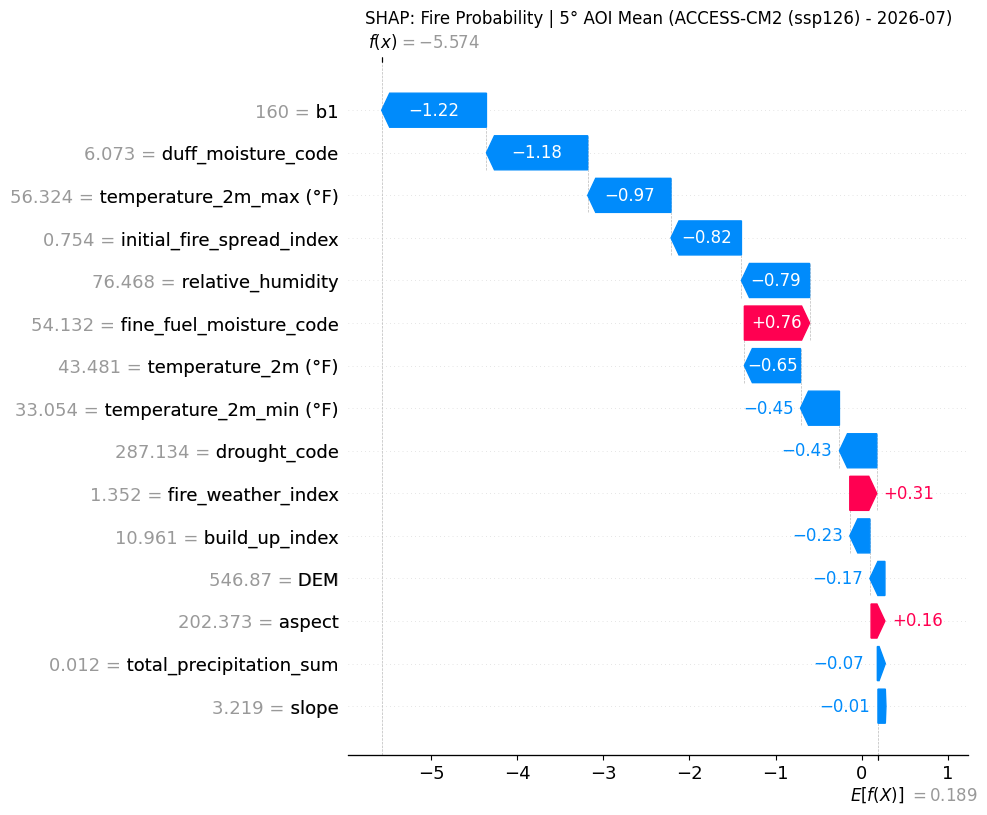


Processing Model: ERA5 | Year: 2022 | Month: 7 | Source: TIF
  Extracted raw CEMS TIFF data.
  Aggregating 1203 pixels...
  Generating SHAP values...
✅ Plot saved to: /home/users/clelland/Model/rerun/problem_diagnosis/shapley_waterfalls/SHAP_5deg_AOI_ERA5_2022_07.png


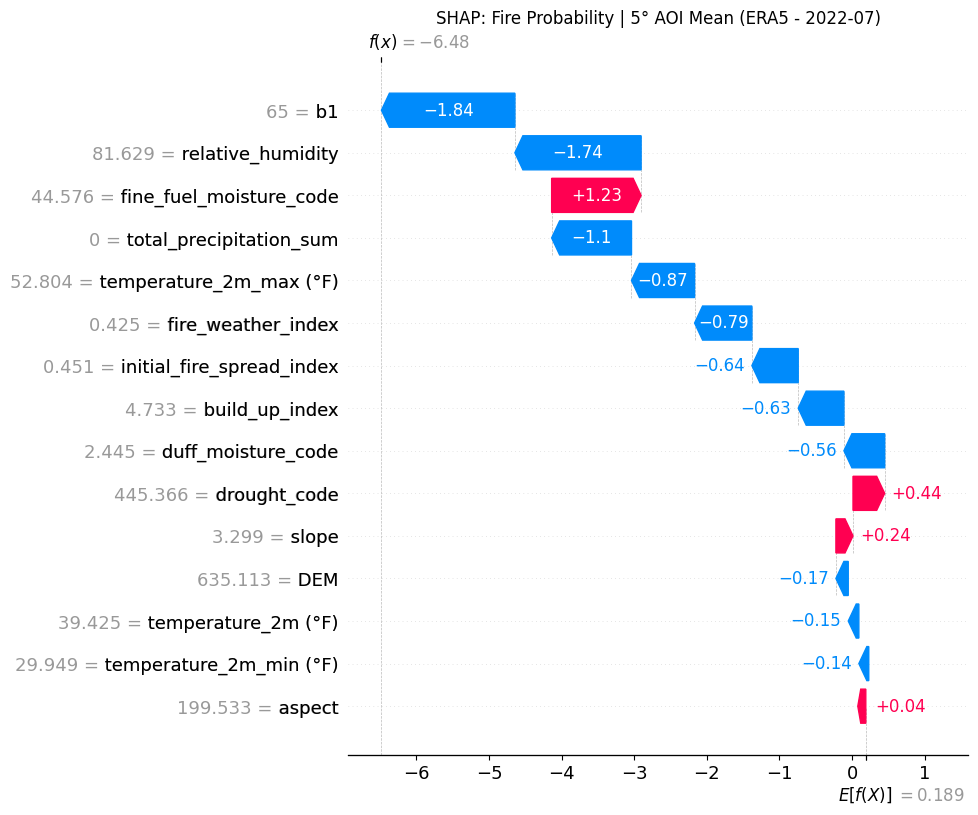

In [1]:
import os
import re
import gc
import numpy as np
import pandas as pd
import xgboost as xgb
import pyarrow.dataset as pa_ds
import rasterio as rio
import rasterio.mask
import shap
import matplotlib.pyplot as plt
import geopandas as gpd
from pathlib import Path
import warnings

# Robust check for PROJ database
import pyproj
if 'CONDA_PREFIX' in os.environ:
    proj_path = os.path.join(os.environ['CONDA_PREFIX'], 'share', 'proj')
    if os.path.exists(proj_path):
        os.environ['PROJ_LIB'] = proj_path
        pyproj.datadir.set_data_dir(proj_path)
    else:
        alt_path = os.path.join(os.environ['CONDA_PREFIX'], 'Library', 'share', 'proj')
        if os.path.exists(alt_path):
            os.environ['PROJ_LIB'] = alt_path
            pyproj.datadir.set_data_dir(alt_path)

warnings.filterwarnings("ignore")

# =====================================================================
# 1. CONFIGURATION
# =====================================================================
# Directories for BOTH data sources
PARQUET_DIR = Path("/gws/ssde/j25b/bas_climate/users/clelland/model/parquet_ACCESS-CM2_ssp126")
CEMS_DIR = Path("/gws/ssde/j25b/bas_climate/users/clelland/model/training_e5l_cems_firecci_new_fwi_with_fraction")
MODEL_PATH = Path("/home/users/clelland/Model/rerun/xgb_final_model.json")
OUT_DIR = Path("/home/users/clelland/Model/rerun/problem_diagnosis/shapley_waterfalls")
BEST_CELL_PATH = Path("/home/users/clelland/Model/rerun/problem_diagnosis/best_match_5deg_cell.geojson")

TARGET_MONTH = 7 # Isolate peak summer conditions

# Define the scenarios to compare
SCENARIOS = [
    {"model": "ACCESS-CM2 (ssp126)", "year": 2026, "source": "parquet"},
    {"model": "ERA5", "year": 2022, "source": "tif"} 
]

FEATURES = [
    "DEM", "slope", "aspect", "b1", "relative_humidity",
    "total_precipitation_sum", "temperature_2m", "temperature_2m_min",
    "temperature_2m_max", "build_up_index", "drought_code",
    "duff_moisture_code", "fine_fuel_moisture_code",
    "fire_weather_index", "initial_fire_spread_index",
]

def norm_str(s): 
    return re.sub(r"[^a-z0-9]", "", str(s).lower())

def run_aoi_shap_explanations():
    OUT_DIR.mkdir(parents=True, exist_ok=True)

    # 1. Load Model & Explainer
    print("Loading XGBoost Model...")
    bst = xgb.Booster()
    bst.load_model(str(MODEL_PATH))
    explainer = shap.TreeExplainer(bst)
    explainer.model._xgb_dmatrix_props = {"enable_categorical": True} # Prevent categorical crash

    # 2. Load Winning 5-Degree Cell
    print("Loading saved 5-degree winning cell...")
    if not BEST_CELL_PATH.exists():
        raise FileNotFoundError("Could not find the saved cell. Run the search script first.")
    roi_gdf = gpd.read_file(BEST_CELL_PATH)
    #roi_6931 = roi_gdf.to_crs("EPSG:6931")
    #aoi_poly_6931 = roi_6931.geometry.iloc[0]
    aoi_poly_6931 = roi_gdf.geometry.iloc[0]

    # 3. Process Scenarios
    for scenario in SCENARIOS:
        t_model = scenario["model"]
        t_year = scenario["year"]
        source = scenario["source"]
        
        print(f"\n{'='*50}")
        print(f"Processing Model: {t_model} | Year: {t_year} | Month: {TARGET_MONTH} | Source: {source.upper()}")
        print(f"{'='*50}")
        
        aoi_df = pd.DataFrame()

        # =================================================================
        # PIPELINE A: FUTURE (PARQUET)
        # =================================================================
        if source == "parquet":
            dataset = pa_ds.dataset(str(PARQUET_DIR), format="parquet", partitioning="hive")
            df = dataset.to_table(
                #filter=(pa_ds.field("model") == t_model) & (pa_ds.field("year") == t_year)
                filter=(pa_ds.field("year") == t_year)
            ).to_pandas()

            if df.empty:
                print(f"[!] No Parquet data found for {t_model} in {t_year}. Skipping.")
                continue
                
            # Filter for specific month
            if 'month' in df.columns:
                df = df[df['month'] == TARGET_MONTH]
                if df.empty:
                    print(f"[!] No Parquet data found for month {TARGET_MONTH}. Skipping.")
                    continue

            print("  Filtering pixels geographically...")
            gdf_points = gpd.GeoDataFrame(
                df,
                geometry=gpd.points_from_xy(df["longitude"], df["latitude"]),
                crs="EPSG:4326"
            )            
            inside = gdf_points.within(aoi_poly_6931)
            aoi_df = df.loc[inside].copy()

            #if not aoi_df.empty:
                # Apply WIE-MIP specific unit conversions (to Kelvin for the model)
                #print("  Applying WIE-MIP unit conversions...")
                #aoi_df['temperature_2m'] += 273.15
                #aoi_df['temperature_2m_max'] += 273.15
                #aoi_df['temperature_2m_min'] += 273.15
                #aoi_df['total_precipitation_sum'] *= 2629.8

        # =================================================================
        # PIPELINE B: CEMS / ERA5 (GeoTIFFs)
        # =================================================================
        elif source == "tif":
            # Extract only the targeted month's TIF files using regex
            tifs = []
            for f in CEMS_DIR.glob(f"cems_e5l_firecci_{t_year}_*.tif"):
                match = re.search(r"firecci_\d{4}_(\d+)_", f.name)
                if match and int(match.group(1)) == TARGET_MONTH:
                    tifs.append(f)
                    
            if not tifs:
                print(f"[!] No GeoTIFFs found for {t_year}-{TARGET_MONTH} in {CEMS_DIR}. Skipping.")
                continue
                
            target_map = {norm_str(f): f for f in FEATURES}
            target_map[norm_str("initial_spread_index")] = "initial_fire_spread_index"
            
            all_months_pixels = []
            for tif_path in sorted(tifs):
                with rio.open(tif_path) as src:
                    roi_proj = roi_gdf.to_crs(src.crs)
                    try:
                        out_img, _ = rasterio.mask.mask(src, roi_proj.geometry, crop=True, nodata=np.nan)
                    except ValueError:
                        continue # AOI doesn't overlap
                        
                    b_map = {target_map[norm_str(desc)]: i for i, desc in enumerate(src.descriptions) if desc and norm_str(desc) in target_map}
                    pixels = {std_name: out_img[idx].flatten() for std_name, idx in b_map.items()}
                    df_pix = pd.DataFrame(pixels).dropna()
                    if not df_pix.empty:
                        all_months_pixels.append(df_pix)
            
            if all_months_pixels:
                aoi_df = pd.concat(all_months_pixels)
                print("  Extracted raw CEMS TIFF data.")
                
                # Apply CEMS-specific scaling for precipitation
                #if "total_precipitation_sum" in aoi_df.columns:
                #    print("  Scaling CEMS/ERA5 precipitation (* 1,000,000)...")
                #    aoi_df["total_precipitation_sum"] *= 1000000

        # =================================================================
        # SHARED: AGGREGATION & SHAP
        # =================================================================
        if aoi_df.empty:
            print("[!] No valid pixels found for this scenario after extraction. Skipping.")
            continue

        print(f"  Aggregating {len(aoi_df)} pixels...")
        aoi_df = aoi_df.dropna(subset=['fire_weather_index'])

        numeric_df = aoi_df.drop(columns=['b1', 'geometry', 'month', 'year', 'model'], errors='ignore').mean(numeric_only=True).to_frame().T
        
        # Categorical handling
        mode_b1 = aoi_df['b1'].round().mode()[0] if 'b1' in aoi_df.columns else 1
        
        pixel_df = numeric_df.copy()
        pixel_df['b1'] = mode_b1
        pixel_df['b1'] = pixel_df['b1'].astype(float).astype(int).astype("category")

        # Ensure exact feature order for XGBoost
        for f in FEATURES:
            if f not in pixel_df.columns:
                pixel_df[f] = np.nan
        X_pixel = pixel_df[FEATURES].copy()

        # Generate SHAP
        print("  Generating SHAP values...")
        shap_values = explainer(X_pixel)

        # --- FAHRENHEIT CONVERSION FOR PLOTTING ---
        # Modify the display values inside the SHAP Explanation object 
        # (This changes the text on the plot without altering the underlying math)
        temp_features = ["temperature_2m", "temperature_2m_max", "temperature_2m_min"]
        
        # 1. Convert values in the data array from Kelvin to Fahrenheit
        for i, col in enumerate(X_pixel.columns):
            if col in temp_features:
                k_val = shap_values[0].data[i]
                f_val = (k_val - 273.15) * 1.8 + 32
                shap_values[0].data[i] = f_val
                
        # 2. Update feature names to show (°F)
        new_feature_names = [f"{col} (°F)" if col in temp_features else col for col in X_pixel.columns]
        shap_values.feature_names = new_feature_names
        # ------------------------------------------

        # Plot and Save
        plt.figure(figsize=(12, 8))
        shap.plots.waterfall(shap_values[0], max_display=15, show=False)
        plt.title(f"SHAP: Fire Probability | 5° AOI Mean ({t_model} - {t_year}-0{TARGET_MONTH})")

        png_name = f"SHAP_5deg_AOI_{t_model}_{t_year}_0{TARGET_MONTH}.png"
        save_path = OUT_DIR / png_name

        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f"✅ Plot saved to: {save_path}")
        
        plt.show()
        plt.close()

if __name__ == "__main__":
    run_aoi_shap_explanations()

Loading XGBoost Model...
Loading saved 5-degree winning cell...

Processing Model: GFDL-ESM4 | Year: 2000 | Month: 7 | Source: PARQUET
  Filtering pixels geographically...
  Applying WIE-MIP unit conversions...
  Aggregating 17918 pixels...
  Generating SHAP values...
✅ Plot saved to: /explore/nobackup/people/spotter5/wiemip/shapley_waterfalls/SHAP_5deg_AOI_GFDL-ESM4_2000_07_prob.png


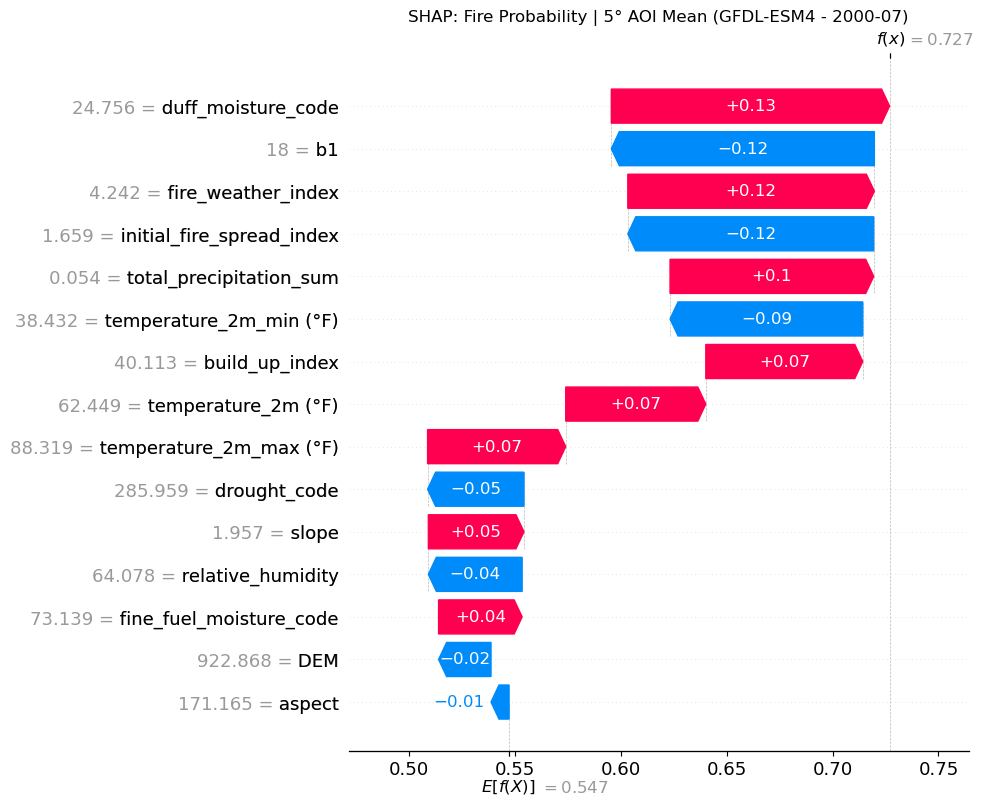


Processing Model: ERA5 | Year: 2001 | Month: 7 | Source: TIF
  Extracted raw CEMS TIFF data.
  Scaling CEMS/ERA5 precipitation (* 1,000,000)...
  Aggregating 8931 pixels...
  Generating SHAP values...


In [ ]:
import os
import re
import gc
import numpy as np
import pandas as pd
import xgboost as xgb
import pyarrow.dataset as pa_ds
import rasterio as rio
import rasterio.mask
import shap
import matplotlib.pyplot as plt
import geopandas as gpd
from pathlib import Path
import warnings
from scipy.special import expit

# Robust check for PROJ database
import pyproj
if 'CONDA_PREFIX' in os.environ:
    proj_path = os.path.join(os.environ['CONDA_PREFIX'], 'share', 'proj')
    if os.path.exists(proj_path):
        os.environ['PROJ_LIB'] = proj_path
        pyproj.datadir.set_data_dir(proj_path)
    else:
        alt_path = os.path.join(os.environ['CONDA_PREFIX'], 'Library', 'share', 'proj')
        if os.path.exists(alt_path):
            os.environ['PROJ_LIB'] = alt_path
            pyproj.datadir.set_data_dir(alt_path)

warnings.filterwarnings("ignore")

# =====================================================================
# 1. CONFIGURATION
# =====================================================================
# Directories for BOTH data sources
PARQUET_DIR = Path("/explore/nobackup/people/spotter5/wiemip/parquet_pixel_dataset_masked")
CEMS_DIR = Path("/explore/nobackup/people/spotter5/clelland_fire_ml/training_e5l_cems_firecci_new_fwi_with_fraction")
MODEL_PATH = Path("/explore/nobackup/people/spotter5/clelland_fire_ml/ml_training/xgb_final_regularized_new_fwi/models/xgb_final_model.json")
OUT_DIR = Path("/explore/nobackup/people/spotter5/wiemip/shapley_waterfalls")
BEST_CELL_PATH = Path("/explore/nobackup/people/spotter5/wiemip/best_match_5deg_cell.geojson")

TARGET_MONTH = 7 # Isolate peak summer conditions

# Define the scenarios to compare
SCENARIOS = [
    {"model": "GFDL-ESM4", "year": 2000, "source": "parquet"},
    {"model": "ERA5", "year": 2001, "source": "tif"} 
]

FEATURES = [
    "DEM", "slope", "aspect", "b1", "relative_humidity",
    "total_precipitation_sum", "temperature_2m", "temperature_2m_min",
    "temperature_2m_max", "build_up_index", "drought_code",
    "duff_moisture_code", "fine_fuel_moisture_code",
    "fire_weather_index", "initial_fire_spread_index",
]

def norm_str(s): 
    return re.sub(r"[^a-z0-9]", "", str(s).lower())

def run_aoi_shap_explanations():
    OUT_DIR.mkdir(parents=True, exist_ok=True)

    # 1. Load Model & Explainer
    print("Loading XGBoost Model...")
    bst = xgb.Booster()
    bst.load_model(str(MODEL_PATH))
    explainer = shap.TreeExplainer(bst)
    explainer.model._xgb_dmatrix_props = {"enable_categorical": True} # Prevent categorical crash

    # 2. Load Winning 5-Degree Cell
    print("Loading saved 5-degree winning cell...")
    if not BEST_CELL_PATH.exists():
        raise FileNotFoundError("Could not find the saved cell. Run the search script first.")
    roi_gdf = gpd.read_file(BEST_CELL_PATH)
    roi_6931 = roi_gdf.to_crs("EPSG:6931")
    aoi_poly_6931 = roi_6931.geometry.iloc[0]

    # 3. Process Scenarios
    for scenario in SCENARIOS:
        t_model = scenario["model"]
        t_year = scenario["year"]
        source = scenario["source"]
        
        print(f"\n{'='*50}")
        print(f"Processing Model: {t_model} | Year: {t_year} | Month: {TARGET_MONTH} | Source: {source.upper()}")
        print(f"{'='*50}")
        
        aoi_df = pd.DataFrame()

        # =================================================================
        # PIPELINE A: WIE-MIP (PARQUET)
        # =================================================================
        if source == "parquet":
            dataset = pa_ds.dataset(str(PARQUET_DIR), format="parquet", partitioning="hive")
            df = dataset.to_table(
                filter=(pa_ds.field("model") == t_model) & (pa_ds.field("year") == t_year)
            ).to_pandas()

            if df.empty:
                print(f"[!] No Parquet data found for {t_model} in {t_year}. Skipping.")
                continue
                
            # Filter for specific month
            if 'month' in df.columns:
                df = df[df['month'] == TARGET_MONTH]
                if df.empty:
                    print(f"[!] No Parquet data found for month {TARGET_MONTH}. Skipping.")
                    continue

            print("  Filtering pixels geographically...")
            gdf_points = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df["easting"], df["northing"]), crs="EPSG:6931")
            inside = gdf_points.within(aoi_poly_6931)
            aoi_df = df.loc[inside].copy()

            if not aoi_df.empty:
                # Apply WIE-MIP specific unit conversions (to Kelvin for the model)
                print("  Applying WIE-MIP unit conversions...")
                aoi_df['temperature_2m'] += 273.15
                aoi_df['temperature_2m_max'] += 273.15
                aoi_df['temperature_2m_min'] += 273.15
                aoi_df['total_precipitation_sum'] *= 2629.8

        # =================================================================
        # PIPELINE B: CEMS / ERA5 (GeoTIFFs)
        # =================================================================
        elif source == "tif":
            # Extract only the targeted month's TIF files using regex
            tifs = []
            for f in CEMS_DIR.glob(f"cems_e5l_firecci_{t_year}_*.tif"):
                match = re.search(r"firecci_\d{4}_(\d+)_", f.name)
                if match and int(match.group(1)) == TARGET_MONTH:
                    tifs.append(f)
                    
            if not tifs:
                print(f"[!] No GeoTIFFs found for {t_year}-{TARGET_MONTH} in {CEMS_DIR}. Skipping.")
                continue
                
            target_map = {norm_str(f): f for f in FEATURES}
            target_map[norm_str("initial_spread_index")] = "initial_fire_spread_index"
            
            all_months_pixels = []
            for tif_path in sorted(tifs):
                with rio.open(tif_path) as src:
                    roi_proj = roi_gdf.to_crs(src.crs)
                    try:
                        out_img, _ = rasterio.mask.mask(src, roi_proj.geometry, crop=True, nodata=np.nan)
                    except ValueError:
                        continue # AOI doesn't overlap
                        
                    b_map = {target_map[norm_str(desc)]: i for i, desc in enumerate(src.descriptions) if desc and norm_str(desc) in target_map}
                    pixels = {std_name: out_img[idx].flatten() for std_name, idx in b_map.items()}
                    df_pix = pd.DataFrame(pixels).dropna()
                    if not df_pix.empty:
                        all_months_pixels.append(df_pix)
            
            if all_months_pixels:
                aoi_df = pd.concat(all_months_pixels)
                print("  Extracted raw CEMS TIFF data.")
                
                # Apply CEMS-specific scaling for precipitation
                if "total_precipitation_sum" in aoi_df.columns:
                    print("  Scaling CEMS/ERA5 precipitation (* 1,000,000)...")
                    aoi_df["total_precipitation_sum"] *= 1000000

        # =================================================================
        # SHARED: AGGREGATION & SHAP
        # =================================================================
        if aoi_df.empty:
            print("[!] No valid pixels found for this scenario after extraction. Skipping.")
            continue

        print(f"  Aggregating {len(aoi_df)} pixels...")
        aoi_df = aoi_df.dropna(subset=['fire_weather_index'])

        numeric_df = aoi_df.drop(columns=['b1', 'geometry', 'month', 'year', 'model'], errors='ignore').mean(numeric_only=True).to_frame().T
        
        # Categorical handling
        mode_b1 = aoi_df['b1'].round().mode()[0] if 'b1' in aoi_df.columns else 1
        
        pixel_df = numeric_df.copy()
        pixel_df['b1'] = mode_b1
        pixel_df['b1'] = pixel_df['b1'].astype(float).astype(int).astype("category")

        # Ensure exact feature order for XGBoost
        for f in FEATURES:
            if f not in pixel_df.columns:
                pixel_df[f] = np.nan
        X_pixel = pixel_df[FEATURES].copy()

        # Generate SHAP
        print("  Generating SHAP values...")
        shap_values = explainer(X_pixel)

        # --- PROBABILITY CONVERSION ---
        # 1. Extract log-odds values
        base_log_odds = shap_values[0].base_values
        total_log_odds = shap_values[0].values.sum()
        final_log_odds = base_log_odds + total_log_odds
        
        # 2. Convert to probability (0 to 1) using expit
        base_prob = expit(base_log_odds)
        final_prob = expit(final_log_odds)
        
        # 3. Proportional scaling to maintain additivity in probability space
        if total_log_odds != 0:
            scaling_factor = (final_prob - base_prob) / total_log_odds
            shap_values.values[0] = shap_values.values[0] * scaling_factor
        
        # 4. Set the new base value
        shap_values.base_values[0] = base_prob
        # ------------------------------

        # --- FAHRENHEIT CONVERSION FOR PLOTTING ---
        temp_features = ["temperature_2m", "temperature_2m_max", "temperature_2m_min"]
        
        for i, col in enumerate(X_pixel.columns):
            if col in temp_features:
                k_val = shap_values[0].data[i]
                f_val = (k_val - 273.15) * 1.8 + 32
                shap_values[0].data[i] = f_val
                
        new_feature_names = [f"{col} (°F)" if col in temp_features else col for col in X_pixel.columns]
        shap_values.feature_names = new_feature_names
        # ------------------------------------------

        # Plot and Save
        plt.figure(figsize=(12, 8))
        shap.plots.waterfall(shap_values[0], max_display=15, show=False)
        plt.title(f"SHAP: Fire Probability | 5° AOI Mean ({t_model} - {t_year}-0{TARGET_MONTH})")

        png_name = f"SHAP_5deg_AOI_{t_model}_{t_year}_0{TARGET_MONTH}_prob.png"
        save_path = OUT_DIR / png_name

        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f"✅ Plot saved to: {save_path}")
        
        plt.show()
        plt.close()

if __name__ == "__main__":
    run_aoi_shap_explanations()